# Implementation of the Article: A Genetic Algorithm for Portfolio Optimization Based on Market Dynamics and Asset Valuations

This section covers the step-by-step implementation of the portfolio optimization method proposed in the paper *A Genetic Algorithm (GA) Approach to the Portfolio Design Based on Market Movements and Asset Valuations*. The approach uses GA to select undervalued stocks while maximizing risk-adjusted returns. 


*By Amro Benramdane and Martin Hamelle, M1 Miage Group 1*


We will follow this flow chart step by step :)

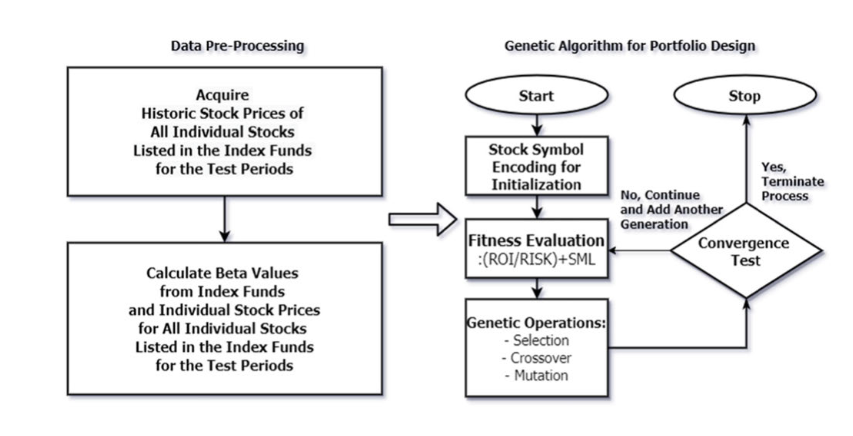

#### Libraries needed

In [7]:
!pip install --upgrade statsmodels
!pip install --upgrade numexpr bottleneck

DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pandas as pd
import datetime
import os
from typing import List, Dict
import statistics
import random
from datetime import datetime

## 1. Data Pre-Processing

In [9]:
def load_sp500_adjclose(folder_path):
    """
    load prices in a dict
    """
    adjclose_dict = {}

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith('.csv'):
            continue

        ticker = os.path.splitext(filename)[0]
        file_path = os.path.join(folder_path, filename)

        try:
            # Lecture du CSV en prenant la première colonne comme index de dates
            df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        except Exception:
            # En cas d’échec de lecture, on passe au fichier suivant
            continue

        if 'Adj Close' not in df.columns:
            # Si pas de colonne "Adj Close", on ignore ce fichier
            continue

        # Récupère la série "Adj Close" telle quelle
        series_adj = df['Adj Close'].copy()
        series_adj.name = ticker

        adjclose_dict[ticker] = series_adj

    return adjclose_dict


In [10]:
def load_sp500_index_daily(csv_path, start_date="2004-01-01", end_date="2020-12-31"):
    
    """Return a pd.Series of S&P 500 index prices for each business day."""
    
    index_df = pd.read_csv(
        csv_path,
        usecols=["Date", "Price"],
        dtype={"Date": "string", "Price": "string"},
    )
    index_df["Date"] = pd.to_datetime(index_df["Date"], format="%m/%d/%Y")
    index_df.set_index("Date", inplace=True)
    index_df.sort_index(inplace=True)
    index_df["Price"] = index_df["Price"].str.replace(",", "", regex=False).astype(float)
    index_df = index_df.loc[start_date:end_date]
    business_days = pd.date_range(start=start_date, end=end_date, freq="B")
    index_daily = index_df["Price"].reindex(business_days).ffill()
    index_daily.name = "SP500_Daily_Price"
    
    return index_daily


In [11]:
def calculate_3year_monthly_beta(
    stock_prices_daily,
    market_prices_daily,
    first_beta_month_yyyy_mm
):
    """
    Compute rolling up-to-36-month beta from daily price data,
    """
    monthly_stock  = stock_prices_daily.resample("ME").last().dropna()
    monthly_market = market_prices_daily.resample("ME").last().dropna()
    data = pd.DataFrame({
        "stock":  monthly_stock,
        "market": monthly_market
    }).dropna()

    year, month = first_beta_month_yyyy_mm.split("-")
    first_ts_candidate = pd.to_datetime(f"{year}-{month}-01") + pd.offsets.MonthEnd(0)

    if first_ts_candidate not in data.index:
        same_month = data.index.to_series().loc[
            (data.index.year == first_ts_candidate.year) &
            (data.index.month == first_ts_candidate.month)
        ]
        if not same_month.empty:
            first_ts = same_month.iloc[0]
        else:
            nearest_idx = data.index.get_indexer([first_ts_candidate], method="nearest")[0]
            first_ts = data.index[nearest_idx]
    else:
        first_ts = first_ts_candidate

    last_month = data.index.max()
    target_months = pd.date_range(start=first_ts, end=last_month, freq="ME")

    data["stock_return"]  = data["stock"].pct_change()
    data["market_return"] = data["market"].pct_change()
    data = data.dropna()

    beta_values = []
    betas_done  = []

    for month_end in target_months:
        if month_end in data.index:
            i = data.index.get_loc(month_end)
            window_start = i - 36
            if window_start >= 0:
                window = data.iloc[window_start:i]
                X = sm.add_constant(window["market_return"])
                y = window["stock_return"]
                beta = sm.OLS(y, X).fit().params["market_return"]
                betas_done.append(float(beta))
                beta_values.append(float(beta))
            else:
                if len(betas_done) == 0:
                    beta_values.append(float("nan"))
                else:
                    median_beta = float(pd.Series(betas_done).median())
                    beta_values.append(median_beta)
        else:
            if len(betas_done) == 0:
                beta_values.append(float("nan"))
            else:
                median_beta = float(pd.Series(betas_done).median())
                beta_values.append(median_beta)

    index_strings = [dt.strftime("%Y-%m") for dt in target_months]
    beta_series = pd.Series(beta_values, index=index_strings, name="Beta")
    return beta_series.bfill()


###  1. Acquire historic stock prices

#### We chose to test our implementation with the *'S&P500'* stocks data

##### All individual stock prices (adjusted) 

In [12]:
folder_path = '/Users/amrobenramdane/Documents/M1Info/Implementation_GAforPM/sp500yf'

start_date = '2002-01-01'
end_date = '2020-12-31'

sp500_stock_dict = load_sp500_adjclose(folder_path)

master_business_days = pd.date_range(start=start_date, end=end_date, freq="B")

sp500_stock_daily = {}

for ticker, daily_series in sp500_stock_dict.items():
    ts = daily_series.reindex(master_business_days).ffill()
    ts.name = ticker
    sp500_stock_daily[ticker] = ts

print(f"Nombre de ticker traités : {len(sp500_stock_daily)}")
print(f"Longueur d'une série quotidienne pour 'ABC' : {len(sp500_stock_daily['ABC'])}")
print(f"Premier index : {sp500_stock_daily['ABC'].index[0]}")
print(f"Dernier index  : {sp500_stock_daily['ABC'].index[-1]}")

print(sp500_stock_dict['AAL']['2008-01'])


Nombre de ticker traités : 505
Longueur d'une série quotidienne pour 'ABC' : 4958
Premier index : 2002-01-01 00:00:00
Dernier index  : 2020-12-31 00:00:00
Date
2008-01-02    12.557317
2008-01-03    11.991672
2008-01-04    11.699421
2008-01-07    11.529728
2008-01-08    10.379581
2008-01-09    10.266455
2008-01-10    11.831406
2008-01-11    11.209197
2008-01-14    11.350606
2008-01-15    11.793694
2008-01-16    11.821978
2008-01-17    11.793694
2008-01-18    12.180223
2008-01-22    11.331751
2008-01-23    12.387624
2008-01-24    11.935106
2008-01-25    11.586291
2008-01-28    12.566745
2008-01-29    12.349913
2008-01-30    12.613881
2008-01-31    13.047543
Name: AAL, dtype: float64


##### S&P500 index prices

In [13]:
csv_path = "S&P-500-Historical-Data.csv"
sp500_index_prices = load_sp500_index_daily(csv_path)
#----here we will use sp500_index_prices-----

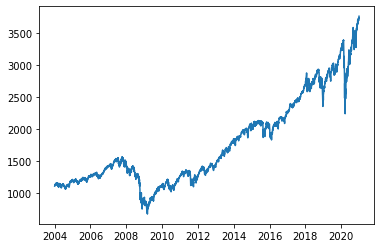

In [14]:
plt.plot(sp500_index_prices)

In [15]:
def compute_monthly_market_return(market_prices_daily):
    """Compute monthly returns from daily market price data."""
    monthly_prices = market_prices_daily.resample("ME").last().dropna()
    monthly_returns = monthly_prices.pct_change().dropna()
    monthly_returns.name = "Market_Return"
    return monthly_returns

In [16]:
market_return = compute_monthly_market_return(sp500_index_prices)
market_return

2004-02-29    0.012201
2004-03-31   -0.016333
2004-04-30   -0.016782
2004-05-31    0.012102
2004-06-30    0.017935
                ...   
2020-08-31    0.070068
2020-09-30   -0.039225
2020-10-31   -0.027654
2020-11-30    0.107523
2020-12-31    0.037138
Freq: ME, Name: Market_Return, Length: 203, dtype: float64

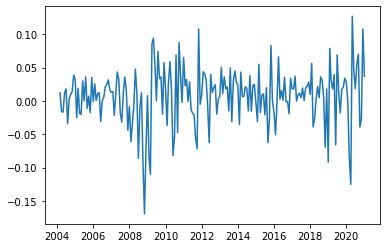

In [17]:
plt.plot(market_return)

#### Conclusion for the data processing part :

We now have three key data structures:

1. **`market_return`**  
   A pandas Series

2. **`sp500_stock_prices`**  
   A dictionary where each key is an S&P 500 ticker and the corresponding value is a pandas Series of that stock’s **daily** adjusted-close prices (one entry for every business day in the date range).

3. **`sp500_index_prices`**  
   A pandas Series containing the S&P 500 index’s **daily** price for each business day from January 2008 through December 2020.

With these in place, all stock and index prices are now aligned on a daily frequency and ready for further calculations (e.g., rolling-beta, portfolio fitness, etc.).


###  2. Compute the Beta for each stock

In [18]:
Beta_dict = {}

Beta_dict['AAPL'] = calculate_3year_monthly_beta(sp500_stock_daily['AAPL'],sp500_index_prices,'2008-01')

Beta_dict['AAPL']

2008-01    2.040542
2008-02    3.060872
2008-03    3.001750
2008-04    2.900944
2008-05    2.859524
             ...   
2020-08    1.147581
2020-09    1.230924
2020-10    1.284232
2020-11    1.296388
2020-12    1.240351
Name: Beta, Length: 156, dtype: float64

#### We have now all the data to start the Genetic algorithm

## 2. Genetic Algorithm

In [19]:
def encode_stocks(stocks: List[str]) -> Dict[str, int]:
    """
    Assign each stock to a unique bit-position in the binary chromosome.
    """
    return {stocks[i]: i for i in range(len(stocks))}

In [20]:
def initialize_population(stocks: List[str], pop_size: int) -> np.ndarray:
    """
    Generate a random population of binary chromosomes (pop_size × N), where N = len(stocks).
    A bit of 1 means that stock is included. Ensures no chromosome is entirely zero.
    """
    N = len(stocks)
    population = np.random.randint(0, 2, size=(pop_size, N), dtype=int)
    for i in range(pop_size):
        if not population[i].any():
            j = np.random.randint(0, N)
            population[i, j] = 1
    return population

Test of the function *'initialize_population'*

In [21]:
stocks = ['AAL','AAP','ABBV','A','ABC','AAPL']

initialize_population(stocks,5) #generation of many portfolios with different stock selection

array([[0, 0, 0, 0, 1, 0],
       [1, 1, 0, 1, 0, 0],
       [0, 0, 1, 0, 1, 0],
       [0, 0, 0, 1, 1, 0],
       [1, 1, 1, 1, 0, 0]])

In [22]:
def compute_capm_series(beta_dict, month_yyyy_mm, market_return, risk_free_rate, stocks_to_include):
    """Compute expected return for each stock using CAPM formula, where beta_dict[stock] is a Series indexed by "YYYY-MM"."""

    month_str = month_yyyy_mm  # expecting "YYYY-MM"
    capm_values = {}

    for stock in stocks_to_include:
        beta_ser = beta_dict.get(stock, None)
        if beta_ser is None or len(beta_ser) == 0:
            raise KeyError(f"No beta series available for '{stock}'.")

        if month_str in beta_ser.index:
            beta_i = float(beta_ser.loc[month_str])
        else:
            valid_months = [m for m in beta_ser.index if m <= month_str]
            if not valid_months:
                raise KeyError(f"No beta exists for '{stock}' before {month_str}.")
            last_month = max(valid_months)
            beta_i = float(beta_ser.loc[last_month])

        if pd.isna(beta_i):
            raise KeyError(f"No beta at {month_str} for '{stock}'.")

        capm_values[stock] = -1 * (risk_free_rate + beta_i * (market_return - risk_free_rate))

    return pd.Series(capm_values, name="CAPM")


In [23]:
def fitness(chrom, TotalFundAmount, price_df, YY_MM, beta, market_return, risk_free):

    AmountStockPurchase = 0
    Stocks = [s for s in list(chrom.index) if chrom[s] == 1]
    if len(Stocks) != 0:
        AllocateFunds = TotalFundAmount / len(Stocks)
        AmountStockPurchase += AllocateFunds
    else:
        AllocateFunds = 0
    RemainderOfFunds = TotalFundAmount - AmountStockPurchase

    capm_series = compute_capm_series(beta, YY_MM, market_return, 0, Stocks)
    per_stock_fs = {}

    for stock in Stocks:

        price_series = price_df[stock][YY_MM]
        price_day0 = price_series.iloc[0]
        share_amount = AllocateFunds / price_day0
        handling_fee0 = share_amount * price_day0 * 0.0007
        remaining_budget = AllocateFunds - (share_amount * price_day0) - handling_fee0

        fs_series = (
            price_series * share_amount
            - price_series * share_amount * 0.0008
            - price_series * share_amount * 0.003
            + remaining_budget
        )
        per_stock_fs[stock] = fs_series

    if per_stock_fs:
        df_fs = pd.concat(per_stock_fs.values(), axis=1)
        df_fs.columns = list(per_stock_fs.keys())
        portfolio_fs_series = df_fs.sum(axis=1)
    else:
        portfolio_fs_series = pd.Series(
            [TotalFundAmount],
            index=[pd.to_datetime(YY_MM + "-01")]
        )

    PorfolioFundStandardization = portfolio_fs_series.iloc[-1]
    LPortfolioCAPM = []

    for stock in Stocks:
        LPortfolioCAPM.append(capm_series[stock][YY_MM].iloc[0])

    PortfolioCAPM = sum(LPortfolioCAPM)

    ROI = (PorfolioFundStandardization - TotalFundAmount) / TotalFundAmount * 100

    mu = portfolio_fs_series.mean()
    sigma = portfolio_fs_series.std(ddof=0)
    Risk = sigma / mu * 100
    Fitness = (ROI - risk_free) / Risk + PortfolioCAPM

    print(f"PorfolioFundStandardization (last day) = {PorfolioFundStandardization}")
    print(f"ROI = {ROI:.2f}%")
    print(f"Risk = {Risk:.2f}")
    print(f"PortfolioCAPM = {PortfolioCAPM:.2f}")
    print(f"Fitness (With CAPM)= {Fitness:.2f}")
    print(f"Fitness (Without CAPM)= {Fitness - PortfolioCAPM:.2f}")
    return Fitness, ROI


Test of the function fitness calculation here *'fitness'*

In [24]:
portfolio = {'AAL': 1, 'AAP': 0, 'ABBV': 0, 'A': 0, 'ABC': 1, 'AAPL': 0}
chromosome = pd.Series(data=portfolio, index=list(portfolio.keys()))
beta_dict = {}

for p in list(portfolio.keys()):
    beta_dict[p] = calculate_3year_monthly_beta(sp500_stock_dict[p], sp500_index_prices, '2008-01')

month = '2008-01'

price_df = pd.DataFrame(sp500_stock_dict)

beta_dict['AAL']


# Appel à la fonction fitness
fitness(chromosome, 10000, price_df, '2008-01', beta_dict, market_return, 0.0)


PorfolioFundStandardization (last day) = 10376.42066559388
ROI = 3.76%
Risk = 3.01
PortfolioCAPM = 0.14
Fitness (With CAPM)= 1.39
Fitness (Without CAPM)= 1.25


(1.3907149156615555, 3.7642066559387968)

**We got approximatly the same results as th example in the article, so it's a good sign :)**

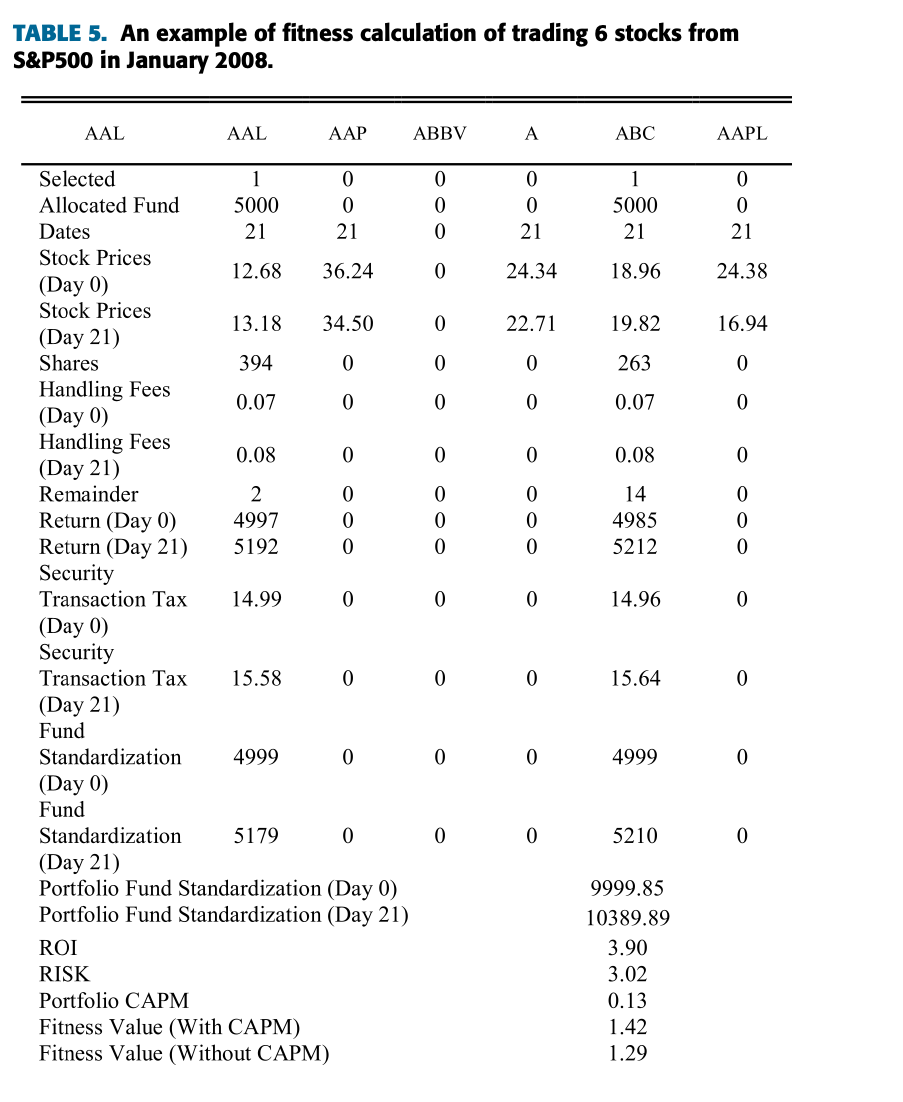

### Genetic Algorithms – Implementation

In [25]:
def tournament_selection(population, fitness_list, tickers):
    """
    Perform tournament selection and print details.

    Args:
        population (List[pd.Series]): Chromosomes (0/1 Series indexed by ticker).
        fitness_list (List[float]): Fitness values corresponding to each chromosome.
        tickers (List[str]): Ordered list of tickers for printing.

    Returns:
        Tuple[List[pd.Series], List[float]]: (new_population, new_fitness_list).
    """
    pop_size = len(population)
    new_population = []
    new_fitness_list = []

    print("\n=== BEFORE SELECTION ===")
    header = "POP#\t" + "\t".join(tickers) + "\tFITNESS"
    print(header)
    for idx, chrom in enumerate(population):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}\t{fitness_list[idx]:.2f}")

    print("\n--- PROCESS OF TOURNAMENT SELECTION ---")
    for i in range(pop_size):
        j = random.randrange(pop_size)
        f_i = fitness_list[i]
        f_j = fitness_list[j]
        if f_i > f_j:
            winner_idx = i
        else:
            winner_idx = j

        print(
            f"Index {i} (fitness {f_i:.2f}) vs Random Index {j} (fitness {f_j:.2f}) → "
            f"Winner: Index {winner_idx} (fitness {fitness_list[winner_idx]:.2f})"
        )

        new_population.append(population[winner_idx].copy())
        new_fitness_list.append(fitness_list[winner_idx])

    print("\n=== AFTER SELECTION ===")
    print(header)
    for idx, (chrom, fit) in enumerate(zip(new_population, new_fitness_list)):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}\t{fit:.2f}")

    return new_population, new_fitness_list


In [26]:
def one_point_crossover(population, tickers):
    """
    Perform one-point crossover and print details.

    Args:
        population (List[pd.Series]): Parent chromosomes.
        tickers (List[str]): Ordered list of tickers for printing.

    Returns:
        List[pd.Series]: Offspring after crossover.
    """
    pop_size = len(population)
    if pop_size == 0:
        return []

    num_genes = len(tickers)
    offspring = []

    print("\n=== BEFORE CROSSOVER ===")
    header = "POP#\t" + "\t".join(tickers)
    print(header)
    for idx, chrom in enumerate(population):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}")

    print("\n--- PROCESS OF CROSSOVER ---")
    for idx in range(0, pop_size, 2):
        parent1 = population[idx]
        if idx + 1 >= pop_size:
            print(f"Population#{idx} has no partner, copied as-is.")
            offspring.append(parent1.copy())
            break

        parent2 = population[idx + 1]
        point = random.randrange(num_genes)

        print(f"\nPair (Index {idx}, Index {idx+1}), Crossover point = {point}")
        print(" Parent1:", "".join(str(int(parent1[t])) for t in tickers))
        print(" Parent2:", "".join(str(int(parent2[t])) for t in tickers))

        child1 = parent1.copy()
        child2 = parent2.copy()
        for g in tickers[point:]:
            child1[g], child2[g] = parent2[g], parent1[g]

        print(" Child1:", "".join(str(int(child1[t])) for t in tickers))
        print(" Child2:", "".join(str(int(child2[t])) for t in tickers))

        offspring.append(child1)
        offspring.append(child2)

    print("\n=== AFTER CROSSOVER ===")
    print(header)
    for idx, chrom in enumerate(offspring):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}")

    return offspring


In [27]:
def mutation(population, mutation_rate, tickers):
    """
    Apply mutation and print details.

    Args:
        population (List[pd.Series]): Chromosomes to mutate.
        mutation_rate (float): Probability to flip each gene.
        tickers (List[str]): Ordered list of tickers for printing.

    Returns:
        List[pd.Series]: Mutated population.
    """
    print("\n=== BEFORE MUTATION ===")
    header = "POP#\t" + "\t".join(tickers)
    print(header)
    for idx, chrom in enumerate(population):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}")

    print("\n--- PROCESS OF MUTATION ---")
    for idx, chrom in enumerate(population):
        for gene in tickers:
            r = random.random()
            if r < mutation_rate:
                old_val = chrom[gene]
                chrom[gene] = 1 - chrom[gene]
                print(
                    f"Index {idx}, gene '{gene}': random={r:.2f} < {mutation_rate} → "
                    f"mutated {old_val}→{chrom[gene]}"
                )

    print("\n=== AFTER MUTATION ===")
    print(header)
    for idx, chrom in enumerate(population):
        genes = "\t".join(str(int(chrom[t])) for t in tickers)
        print(f"{idx}\t{genes}")

    return population


In [28]:
def genetic_algorithm(
    tickers,
    mutation_rate,
    max_generations,
    TotalFundAmount,
    price_df,
    YY_MM,
    beta,
    market_return,
    risk_free
):
    """
    Run a genetic algorithm to optimize portfolio selection, with detailed prints.

    Args:
        tickers (List[str]): List of tickers (genes).
        mutation_rate (float): Probability of mutating each gene.
        max_generations (int): Number of generations to evolve.
        TotalFundAmount (float): Total funds to allocate.
        price_df (Dict[str, pd.DataFrame]): For each ticker, DataFrame of daily prices.
        YY_MM (str): "YYYY-MM" representing the current month.
        beta (Dict[str, pd.Series]): Beta series (index "YYYY-MM") for each ticker.
        market_return (Union[float, pd.Series]): Market return scalar or series by "YYYY-MM".
        risk_free (float): Risk-free rate.

    Returns:
        Tuple[pd.Series, float]: (best_chromosome, best_ROI).
    """
    pop_size = len(tickers)

    # 1) Initialize population: pop_size random 0/1 chromosomes
    population = []
    for _ in range(pop_size):
        chrom = pd.Series({t: random.choice([0, 1]) for t in tickers})
        population.append(chrom)

    # 2) Evaluate initial fitness and ROI lists
    fitness_list = []
    roi_list = []
    for chrom in population:
        fit, roi = fitness(chrom, TotalFundAmount, price_df, YY_MM, beta, market_return, risk_free)
        fitness_list.append(fit)
        roi_list.append(roi)

    for gen in range(max_generations):
        print(f"\n\n######## Generation {gen} ########")

        # 3) Selection
        population, fitness_list = tournament_selection(population, fitness_list, tickers)

        # 4) Crossover
        population = one_point_crossover(population, tickers)

        # 5) Mutation
        population = mutation(population, mutation_rate, tickers)

        # 6) Re-evaluate fitness and ROI for new population
        fitness_list = []
        roi_list = []
        for chrom in population:
            fit, roi = fitness(chrom, TotalFundAmount, price_df, YY_MM, beta, market_return, risk_free)
            fitness_list.append(fit)
            roi_list.append(roi)

        # 7) Print fitness after this generation
        print("\n--- FITNESS AFTER GENERATION ---")
        header = "POP#\t" + "\t".join(tickers) + "\tFITNESS"
        print(header)
        for idx, chrom in enumerate(population):
            genes = "\t".join(str(int(chrom[t])) for t in tickers)
            print(f"{idx}\t{genes}\t{fitness_list[idx]:.2f}")

    # 8) Identify best chromosome by fitness
    best_idx = max(range(len(population)), key=lambda i: fitness_list[i])
    best_chrom = population[best_idx]
    best_roi = roi_list[best_idx]

    print(f"\nBest Chromosome (Index {best_idx}, Fitness {fitness_list[best_idx]:.2f}, ROI {best_roi:.2f}%):")
    print("\t" + " ".join(f"{t}:{int(best_chrom[t])}" for t in tickers))
    return best_chrom, best_roi


Example with this stocks : **`'AAL','AAP','ABBV','A','ABC','AAPL'`** and this date **`'2019-01'`**

In [29]:
stocks = ['AAL','AAP','ABBV','A','ABC','AAPL']
mutation_rate = 0.01
max_generations = 100
TotalFundAmount = 10000
#price_df
YY_MM = '2019-01'
beta_dict = {}

for p in stocks:
     beta_dict[p] = calculate_3year_monthly_beta(sp500_stock_dict[p],sp500_index_prices,YY_MM)
        


In [30]:
optPorfolio, ROI = genetic_algorithm(
     stocks,
     mutation_rate,
     max_generations,
     TotalFundAmount,
     price_df,
     YY_MM,
     beta_dict,
     market_return,
     0.0
 )

PorfolioFundStandardization (last day) = 10303.810225991108
ROI = 3.04%
Risk = 1.48
PortfolioCAPM = -0.46
Fitness (With CAPM)= 1.59
Fitness (Without CAPM)= 2.05
PorfolioFundStandardization (last day) = 10417.04970493642
ROI = 4.17%
Risk = 1.95
PortfolioCAPM = -0.54
Fitness (With CAPM)= 1.60
Fitness (Without CAPM)= 2.13
PorfolioFundStandardization (last day) = 10015.462959080558
ROI = 0.15%
Risk = 1.74
PortfolioCAPM = -0.24
Fitness (With CAPM)= -0.15
Fitness (Without CAPM)= 0.09
PorfolioFundStandardization (last day) = 10393.16439285762
ROI = 3.93%
Risk = 1.84
PortfolioCAPM = -0.36
Fitness (With CAPM)= 1.78
Fitness (Without CAPM)= 2.14
PorfolioFundStandardization (last day) = 10841.979972119727
ROI = 8.42%
Risk = 2.90
PortfolioCAPM = -0.34
Fitness (With CAPM)= 2.57
Fitness (Without CAPM)= 2.90
PorfolioFundStandardization (last day) = 10994.218752145913
ROI = 9.94%
Risk = 4.05
PortfolioCAPM = -0.32
Fitness (With CAPM)= 2.14
Fitness (Without CAPM)= 2.45


######## Generation 0 ########

=

PorfolioFundStandardization (last day) = 10592.157492901657
ROI = 5.92%
Risk = 1.77
PortfolioCAPM = -0.22
Fitness (With CAPM)= 3.13
Fitness (Without CAPM)= 3.35
PorfolioFundStandardization (last day) = 10592.157492901657
ROI = 5.92%
Risk = 1.77
PortfolioCAPM = -0.22
Fitness (With CAPM)= 3.13
Fitness (Without CAPM)= 3.35
PorfolioFundStandardization (last day) = 10592.157492901657
ROI = 5.92%
Risk = 1.77
PortfolioCAPM = -0.22
Fitness (With CAPM)= 3.13
Fitness (Without CAPM)= 3.35
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	0	1	0	3.13
1	0	1	0	0	1	0	3.13
2	0	1	0	0	1	0	3.13
3	0	1	0	0	1	0	3.13
4	0	1	0	0	1	0	3.13
5	0	1	0	1	1	0	3.34


######## Generation 8 ########

=== BEFORE SELECTION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	0	1	0	3.13
1	0	1	0	0	1	0	3.13
2	0	1	0	0	1	0	3.13
3	0	1	0	0	1	0	3.13
4

PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	1	1	0	3.34
1	0	1	0	1	1	1	2.75
2	0	1	0	1	1	0	3.34
3	0	1	0	1	1	0	3.34
4	0	1	0	1	1	0	3.34
5	0	1	0	1	1	0	3.34


######## Generation 15 ########

=== BEFORE SELECTION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	1	1	0	3.34
1	0	1	0	1	1	1	2.75
2	0	1	0	1	1	0	3.34
3	0	1	0	1	1	0	3.34
4	0	1	0	1	1	0	3.34
5	0	1	0	1	1	0	3.34

--- PROCESS OF TOURNAMENT SELECTION ---
Index 0 (fitness 3.34) vs Random Index 2 (fitness 3.34) → Winner: Index 2 (fitness 3.34)
Index 1 (fitness 2.75) vs Random Index 0 (fitness 3.34) → Winner: Index 0 (fitness 3.34)
Index 2 (fitness 3.34) vs Random Index 2 (fitness 3.34) → Winner: Index 2 (fitness 3.34)
Index 3 (fitness 3.34) vs Random Index 3 (fitness 3.34) → Winner: Index 3 (fitness 3.34)
Index 4 (fitness 3.34) vs Random Index 4 (fitnes

PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	1	1	0	3.34
1	0	1	0	1	1	0	3.34
2	0	1	0	1	1	0	3.34
3	0	1	0	1	1	0	3.34
4	0	1	0	1	1	0	3.34
5	0	1	0	1	1	0	3.34


######## Generation 21 ########

=== BEFORE SELECTION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	1	0	1	1	0	3.34
1	0	1	0	1	1	0	3.34
2	0	1	0	1	1	0	3.34
3	0	1	0	1	1	0	3.34
4	0	1	0	1	1	0	3.34
5	0	1	0	1	1	0	3.34

--- PROCESS OF TOURNAMENT SELECTION ---
Index 0 (fitness 3.34) vs Random Index 0 (fitness 3.34) → Winner: Index 0 (fitness 3.34)
Index 1 (fitness 3.34) vs Random Index 0 (fitness 3.34) → Winner: Index 0 (fitness 3.34)
Index 2 (fitness 3.34) vs Random Index 0 (fitness 3.34) → Winner: Index 0 (fitness 3.34)
Index 3 (fitness 3.34) vs Random Index 2 (fitness 3.34) → Winner: Index 2 (fitness 3.34)
Index 4 (fitness 3.34) vs Random Index 3 (fitnes

PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66
PorfolioFundStandardization (last day) = 10903.4752671542
ROI = 9.03%
Risk = 2.47
PortfolioCAPM = -0.32
Fitness (With CAPM)= 3.34
Fitness (Without CAPM)= 3.66

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP

...

4	0	0	0	0	1	0
5	0	0	0	0	1	0
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk = 3.11
PortfolioCAPM = -0.11
Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69


POP#	AAL	AAP	ABBV	A	ABC	AAPL
0	0	0	0	0	1	0
1	0	0	0	0	1	0
2	0	0	0	0	0	0
3	0	0	0	0	0	0
4	0	0	0	0	1	0
5	0	0	0	0	1	0

--- PROCESS OF CROSSOVER ---

Pair (Index 0, Index 1), Crossover point = 0
 Parent1: 000010
 Parent2: 000010
 Child1: 000010
 Child2: 000010

Pair (Index 2, Index 3), Crossover point = 1
 Parent1: 000000
 Parent2: 000000
 Child1: 000000
 Child2: 000000

Pair (Index 4, Index 5), Crossover point = 3
 Parent1: 000010
 Parent2: 000010
 Child1: 000010
 Child2: 000010

=== AFTER CROSSOVER ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL
0	0	0	0	0	1	0
1	0	0	0	0	1	0
2	0	0	0	0	0	0
3	0	0	0	0	0	0
4	0	0	0	0	1	0
5	0	0	0	0	1	0

=== BEFORE MUTATION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL
0	0	0	0	0	1	0
1	0	0	0	0	1	0
2	0	0	0	0	0	0
3	0	0	0	0	0	0
4	0	0	0	0	1	0
5	0	0	0	0	1	0

--- PROCESS OF MUTATION ---

=== AFTER MUTATION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL
0	0	0	0	0	1	0
1	0	0	0	0	1	0
2	0	0	0	0	0	0
3	0	0	0	0	0	0
4	0	0	0	0	1	0
5	0	0	0	0	1	0
PorfolioFundStandardization (last day) = 11148.567260411743
ROI = 11.49%
Risk =

/var/folders/hb/h4__28ks36zd23ksxv880pwc0000gn/T/ipykernel_54554/3313564435.py:54: RuntimeWarning: invalid value encountered in scalar divide
  Fitness = (ROI - risk_free) / Risk + PortfolioCAPM
/var/folders/hb/h4__28ks36zd23ksxv880pwc0000gn/T/ipykernel_54554/3313564435.py:54: RuntimeWarning: invalid value encountered in scalar divide
  Fitness = (ROI - risk_free) / Risk + PortfolioCAPM
/var/folders/hb/h4__28ks36zd23ksxv880pwc0000gn/T/ipykernel_54554/3313564435.py:54: RuntimeWarning: invalid value encountered in scalar divide
  Fitness = (ROI - risk_free) / Risk + PortfolioCAPM
/var/folders/hb/h4__28ks36zd23ksxv880pwc0000gn/T/ipykernel_54554/3313564435.py:54: RuntimeWarning: invalid value encountered in scalar divide
  Fitness = (ROI - risk_free) / Risk + PortfolioCAPM
/var/folders/hb/h4__28ks36zd23ksxv880pwc0000gn/T/ipykernel_54554/3313564435.py:54: RuntimeWarning: invalid value encountered in scalar divide
  Fitness = (ROI - risk_free) / Risk + PortfolioCAPM
/var/folders/hb/h4__28ks3


ROI = 8.68%
Risk = 3.52
PortfolioCAPM = -0.33
Fitness (With CAPM)= 2.13
Fitness (Without CAPM)= 2.46

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	0	0	0	1	0	3.57
1	0	0	0	1	1	0	3.36
2	0	0	0	0	1	0	3.57
3	0	0	0	0	1	0	3.57
4	0	0	0	0	1	0	3.57
5	1	0	0	0	1	1	2.13


######## Generation 91 ########

=== BEFORE SELECTION ===
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	0	0	0	1	0	3.57
1	0	0	0	1	1	0	3.36
2	0	0	0	0	1	0	3.57
3	0	0	0	0	1	0	3.57
4	0	0	0	0	1	0	3.57
5	1	0	0	0	1	1	2.13

--- PROCESS OF TOURNAMENT SELECTION ---
Index 0 (fitness 3.57) vs Random Index 0 (fitness 3.57) → Winner: Index 0 (fitness 3.57)
Index 1 (fitness 3.36) vs Random Index 2 (fitness 3.57) → Winner: Index 2 (fitness 3.57)
Index 2 (fitness 3.57) vs Random Index 0 (fitness 3.57) → Winner: Index 0 (fitness 3.57)
Index 3 (fitness 3.57) vs Random Index 3 (fitness 3.57) → Winner: Index 3 (fitness 3.57)
Index 4 (fitness 3.57) vs Random Index 5 (fitness 2.13) → Winner: Index 4 (fitness 3.57)
Index 5 (fitness

Fitness (With CAPM)= 3.57
Fitness (Without CAPM)= 3.69

--- FITNESS AFTER GENERATION ---
POP#	AAL	AAP	ABBV	A	ABC	AAPL	FITNESS
0	0	0	0	0	1	0	3.57
1	0	0	0	0	1	0	3.57
2	0	0	0	0	1	0	3.57
3	0	0	0	0	1	0	3.57
4	0	0	0	0	1	0	3.57
5	0	0	0	0	1	0	3.57

Best Chromosome (Index 0, Fitness 3.57, ROI 11.49%):
	AAL:0 AAP:0 ABBV:0 A:0 ABC:1 AAPL:0


We got the following result :

 **`Best Chromosome (Index 0, Fitness 3.57, ROI 11.49%):`**
	 **`AAL:0 AAP:0 ABBV:0 A:0 ABC:1 AAPL:0`**

In [31]:
def plot_optimal_portfolio_vs_index(opt_chrom, YY_MM, price_df, index_series):
    """
    Plot the optimal chromosome’s portfolio vs a market index over the specified month.

    Args:
        opt_chrom (pd.Series): Binary Series indexed by ticker; genes = 1 if selected.
        YY_MM (str): Month string "YYYY-MM".
        price_df (Dict[str, pd.DataFrame]): For each ticker, a DataFrame of daily prices.
                                            Expects that price_df[ticker][YY_MM] returns a pd.Series of daily prices.
        index_series (pd.Series): Daily market index prices (e.g. S&P 500) indexed by date (DatetimeIndex).

    Returns:
        None: Displays a matplotlib plot of normalized portfolio vs normalized index.
    """
    # 1) Extract all selected tickers
    selected = [ticker for ticker, gene in opt_chrom.items() if gene == 1]
    if not selected:
        raise ValueError("No tickers selected in the optimal chromosome.")

    # 2) Build a DataFrame of daily prices for each selected ticker for the given month
    df_prices = pd.DataFrame()
    for ticker in selected:
        daily = price_df[ticker][YY_MM]  # pd.Series indexed by date
        df_prices[ticker] = daily

    # 3) Align data: find common trading days between all tickers and the index
    common_dates = df_prices.index.intersection(index_series.index)
    df_prices = df_prices.loc[common_dates]
    index_data = index_series.loc[common_dates]

    # 4) Normalize each stock’s price series to 100 at the first date
    base_date = common_dates[0]
    df_norm = df_prices.div(df_prices.loc[base_date]) * 100  # each column normalized

    # 5) Compute portfolio as equal-weight average of normalized prices
    portfolio_norm = df_norm.mean(axis=1)

    # 6) Normalize the index to 100 at the same base date
    index_norm = index_data / index_data.loc[base_date] * 100

    # 7) Plot both
    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_norm.index, portfolio_norm.values, label="Portfolio (Normalized)")
    plt.plot(index_norm.index, index_norm.values, label="Market Index (Normalized)", linestyle='--')
    plt.xlabel("Date")
    plt.ylabel("Normalized Value (Base = 100)")
    plt.title(f"Optimal Portfolio vs Market Index ({YY_MM})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Comparison between the portfolio found and the index (here S&P500)**

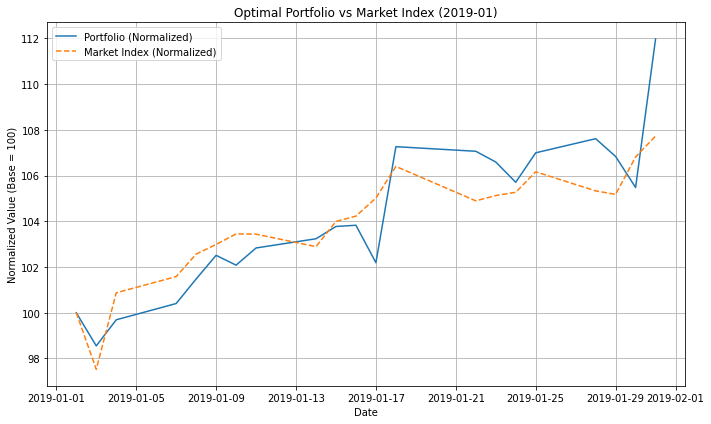

In [32]:
plot_optimal_portfolio_vs_index(optPorfolio,YY_MM,price_df,sp500_index_prices)

### Conclusion : Comparison of the ROIs (CAPM+ vs S&P500)

In [116]:
import pandas as pd
import contextlib
import io
import warnings
import sys

def rolling_cumulative_ROI(
    X,
    all_months,
    price_df,
    snp500_series,
    beta_dict,
    market_return_series,
    risk_free_rate,
    mutation_rate,
    max_generations,
    TotalFundAmount
):
    """
    Compute cumulative monthly ROI for an optimized portfolio vs S&P500 over a rolling X-month window,
    suppressing any prints and warnings from the underlying genetic_algorithm calls.
    """
    n = len(all_months)
    roi_portfolio = []
    roi_snp = []

    for idx in range(X, n):
        t = all_months[idx]

        # Redirect stdout and stderr to suppress prints, and ignore warnings
        f_stdout = io.StringIO()
        f_stderr = io.StringIO()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(f_stdout), contextlib.redirect_stderr(f_stderr):
                opt_chrom, roi_t = genetic_algorithm(
                    tickers=list(price_df.keys()),
                    mutation_rate=mutation_rate,
                    max_generations=max_generations,
                    TotalFundAmount=TotalFundAmount,
                    price_df=price_df,
                    YY_MM=t,
                    beta=beta_dict,
                    market_return=market_return_series,
                    risk_free=risk_free_rate
                )

        roi_portfolio.append(roi_t)

        sp500_month = snp500_series[t]
        first_day = sp500_month.index[0]
        last_day = sp500_month.index[-1]
        roi_snp_t = (sp500_month.loc[last_day] - sp500_month.loc[first_day]) / sp500_month.loc[first_day] * 100
        roi_snp.append(roi_snp_t)

    index_months = all_months[X:]
    roi_portfolio = pd.Series(roi_portfolio, index=index_months).astype(float)
    roi_snp = pd.Series(roi_snp, index=index_months).astype(float)

    cum_port = (roi_portfolio / 100 + 1).cumprod() * 100
    cum_snp = (roi_snp / 100 + 1).cumprod() * 100

    return cum_port, cum_snp


In [48]:
filtered_sp500 = {
        ticker: df
        for ticker, df in sp500_stock_dict.items()
        # Ensure the DataFrame has a DatetimeIndex; compare its minimum date directly
        if isinstance(df.index, pd.DatetimeIndex) and df.index.min() < datetime(2009, 1, 1)
    }
    
pricefiltered_df = pd.DataFrame(filtered_sp500)

In [92]:
all_months = pd.period_range("2014-01", "2018-12", freq="M").astype(str)

In [36]:
beta_dict = {}
    
for p in list(sp500_stock_dict.keys()):
    beta_dict[p] = calculate_3year_monthly_beta(sp500_stock_dict[p],sp500_index_prices,'2008-01')

In [117]:
cum_port_3m, cum_snp_3m = rolling_cumulative_ROI(
        3,
        all_months,
        price_dfTest,
        sp500_index_prices,
        beta_dict,
        market_return,
        0.01,
        0.02,
        100,
        10000
    )
    

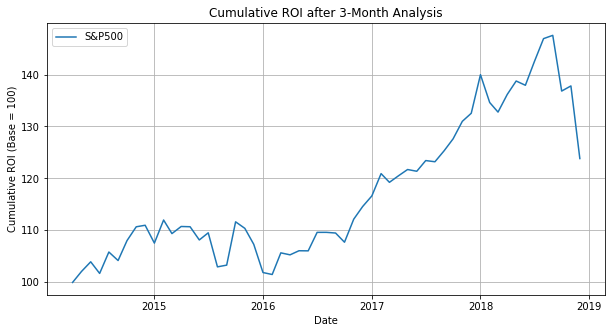

In [119]:
# Supposons que cum_port_3m.index soit de type Index de chaînes "YYYY-MM" ou DateTimeIndex
# On convertit explicitement en datetime si nécessaire :
dates_port = pd.to_datetime(cum_port_3m.index)
dates_snp  = pd.to_datetime(cum_snp_3m.index)

plt.figure(figsize=(10, 5))
plt.plot(dates_snp,  cum_snp_3m.values,  label="S&P500")
plt.xlabel("Date")
plt.ylabel("Cumulative ROI (Base = 100)")
plt.title("Cumulative ROI after 3-Month Analysis")
plt.legend()
plt.grid(True)
plt.show()


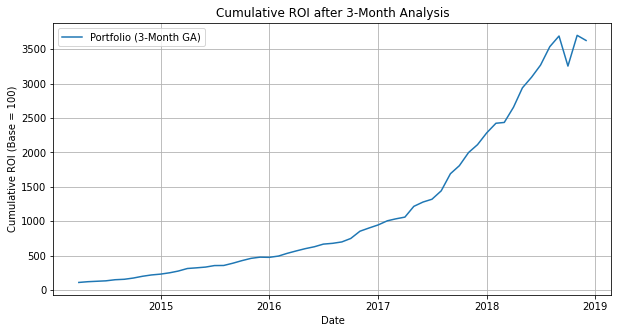

In [120]:
plt.figure(figsize=(10, 5))

plt.plot(dates_port, cum_port_3m.values, label="Portfolio (3-Month GA)")
plt.xlabel("Date")
plt.ylabel("Cumulative ROI (Base = 100)")
plt.title("Cumulative ROI after 3-Month Analysis")
plt.legend()
plt.grid(True)
plt.show()

### This is consistent with the findings of the article. The ROI of our portfolio is lower because we selected only a small subset of the 500 stocks due to computational limitations. Nevertheless, this highlights the effectiveness of the genetic algorithms and the overall relevance of the article.